In [1]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder

print(os.getcwd())
os.chdir("..")
print(os.getcwd())

/workspace/notebooks
/workspace


In [2]:
print(ImageFolder.__doc__)

A generic data loader where the images are arranged in this way by default: ::

        root/dog/xxx.png
        root/dog/xxy.png
        root/dog/[...]/xxz.png

        root/cat/123.png
        root/cat/nsdf3.png
        root/cat/[...]/asd932_.png

    This class inherits from :class:`~torchvision.datasets.DatasetFolder` so
    the same methods can be overridden to customize the dataset.

    Args:
        root (str or ``pathlib.Path``): Root directory path.
        transform (callable, optional): A function/transform that takes in a PIL image
            and returns a transformed version. E.g, ``transforms.RandomCrop``
        target_transform (callable, optional): A function/transform that takes in the
            target and transforms it.
        loader (callable, optional): A function to load an image given its path.
        is_valid_file (callable, optional): A function that takes path of an Image file
            and check if the file is a valid file (used to check of corrupt fi

In [3]:
dataset = ImageFolder("./dataset/raw", transform=ToTensor())
len(dataset), dataset.classes, dataset.class_to_idx

(15154,
 ['COVID', 'Normal', 'Viral Pneumonia'],
 {'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2})

In [4]:
loader = DataLoader(dataset, batch_size=1)
len(loader), next(iter(loader))

(15154,
 [tensor([[[[0.7255, 0.1569, 0.0000,  ..., 0.0000, 0.0941, 0.5137],
            [0.2941, 0.0549, 0.0000,  ..., 0.0000, 0.0314, 0.1647],
            [0.0431, 0.0078, 0.0000,  ..., 0.0039, 0.0118, 0.0471],
            ...,
            [0.3059, 0.2431, 0.2667,  ..., 0.0118, 0.0510, 0.1059],
            [0.4078, 0.2902, 0.2941,  ..., 0.0039, 0.0902, 0.3255],
            [0.6118, 0.3529, 0.3059,  ..., 0.0039, 0.1765, 0.6549]],
  
           [[0.7255, 0.1569, 0.0000,  ..., 0.0000, 0.0941, 0.5137],
            [0.2941, 0.0549, 0.0000,  ..., 0.0000, 0.0314, 0.1647],
            [0.0431, 0.0078, 0.0000,  ..., 0.0039, 0.0118, 0.0471],
            ...,
            [0.3059, 0.2431, 0.2667,  ..., 0.0118, 0.0510, 0.1059],
            [0.4078, 0.2902, 0.2941,  ..., 0.0039, 0.0902, 0.3255],
            [0.6118, 0.3529, 0.3059,  ..., 0.0039, 0.1765, 0.6549]],
  
           [[0.7255, 0.1569, 0.0000,  ..., 0.0000, 0.0941, 0.5137],
            [0.2941, 0.0549, 0.0000,  ..., 0.0000, 0.0314, 0.1647]

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=1500)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

temp = float('inf')
counts = [0, 0, 0]
for path, cls in dataset.imgs:
    counts[cls] += 1
    if cls == temp: continue

    img = cv.imread(path)
    axes[cls].set_title(f"{cls}: {idx_to_class[cls]}")
    axes[cls].imshow(img.squeeze())
    axes[cls].axis('off')
    temp = cls

plt.show()
for i in range(3): print(f"{idx_to_class[i]}: {counts[i]}")

COVID: 3617
Normal: 10192
Viral Pneumonia: 1345


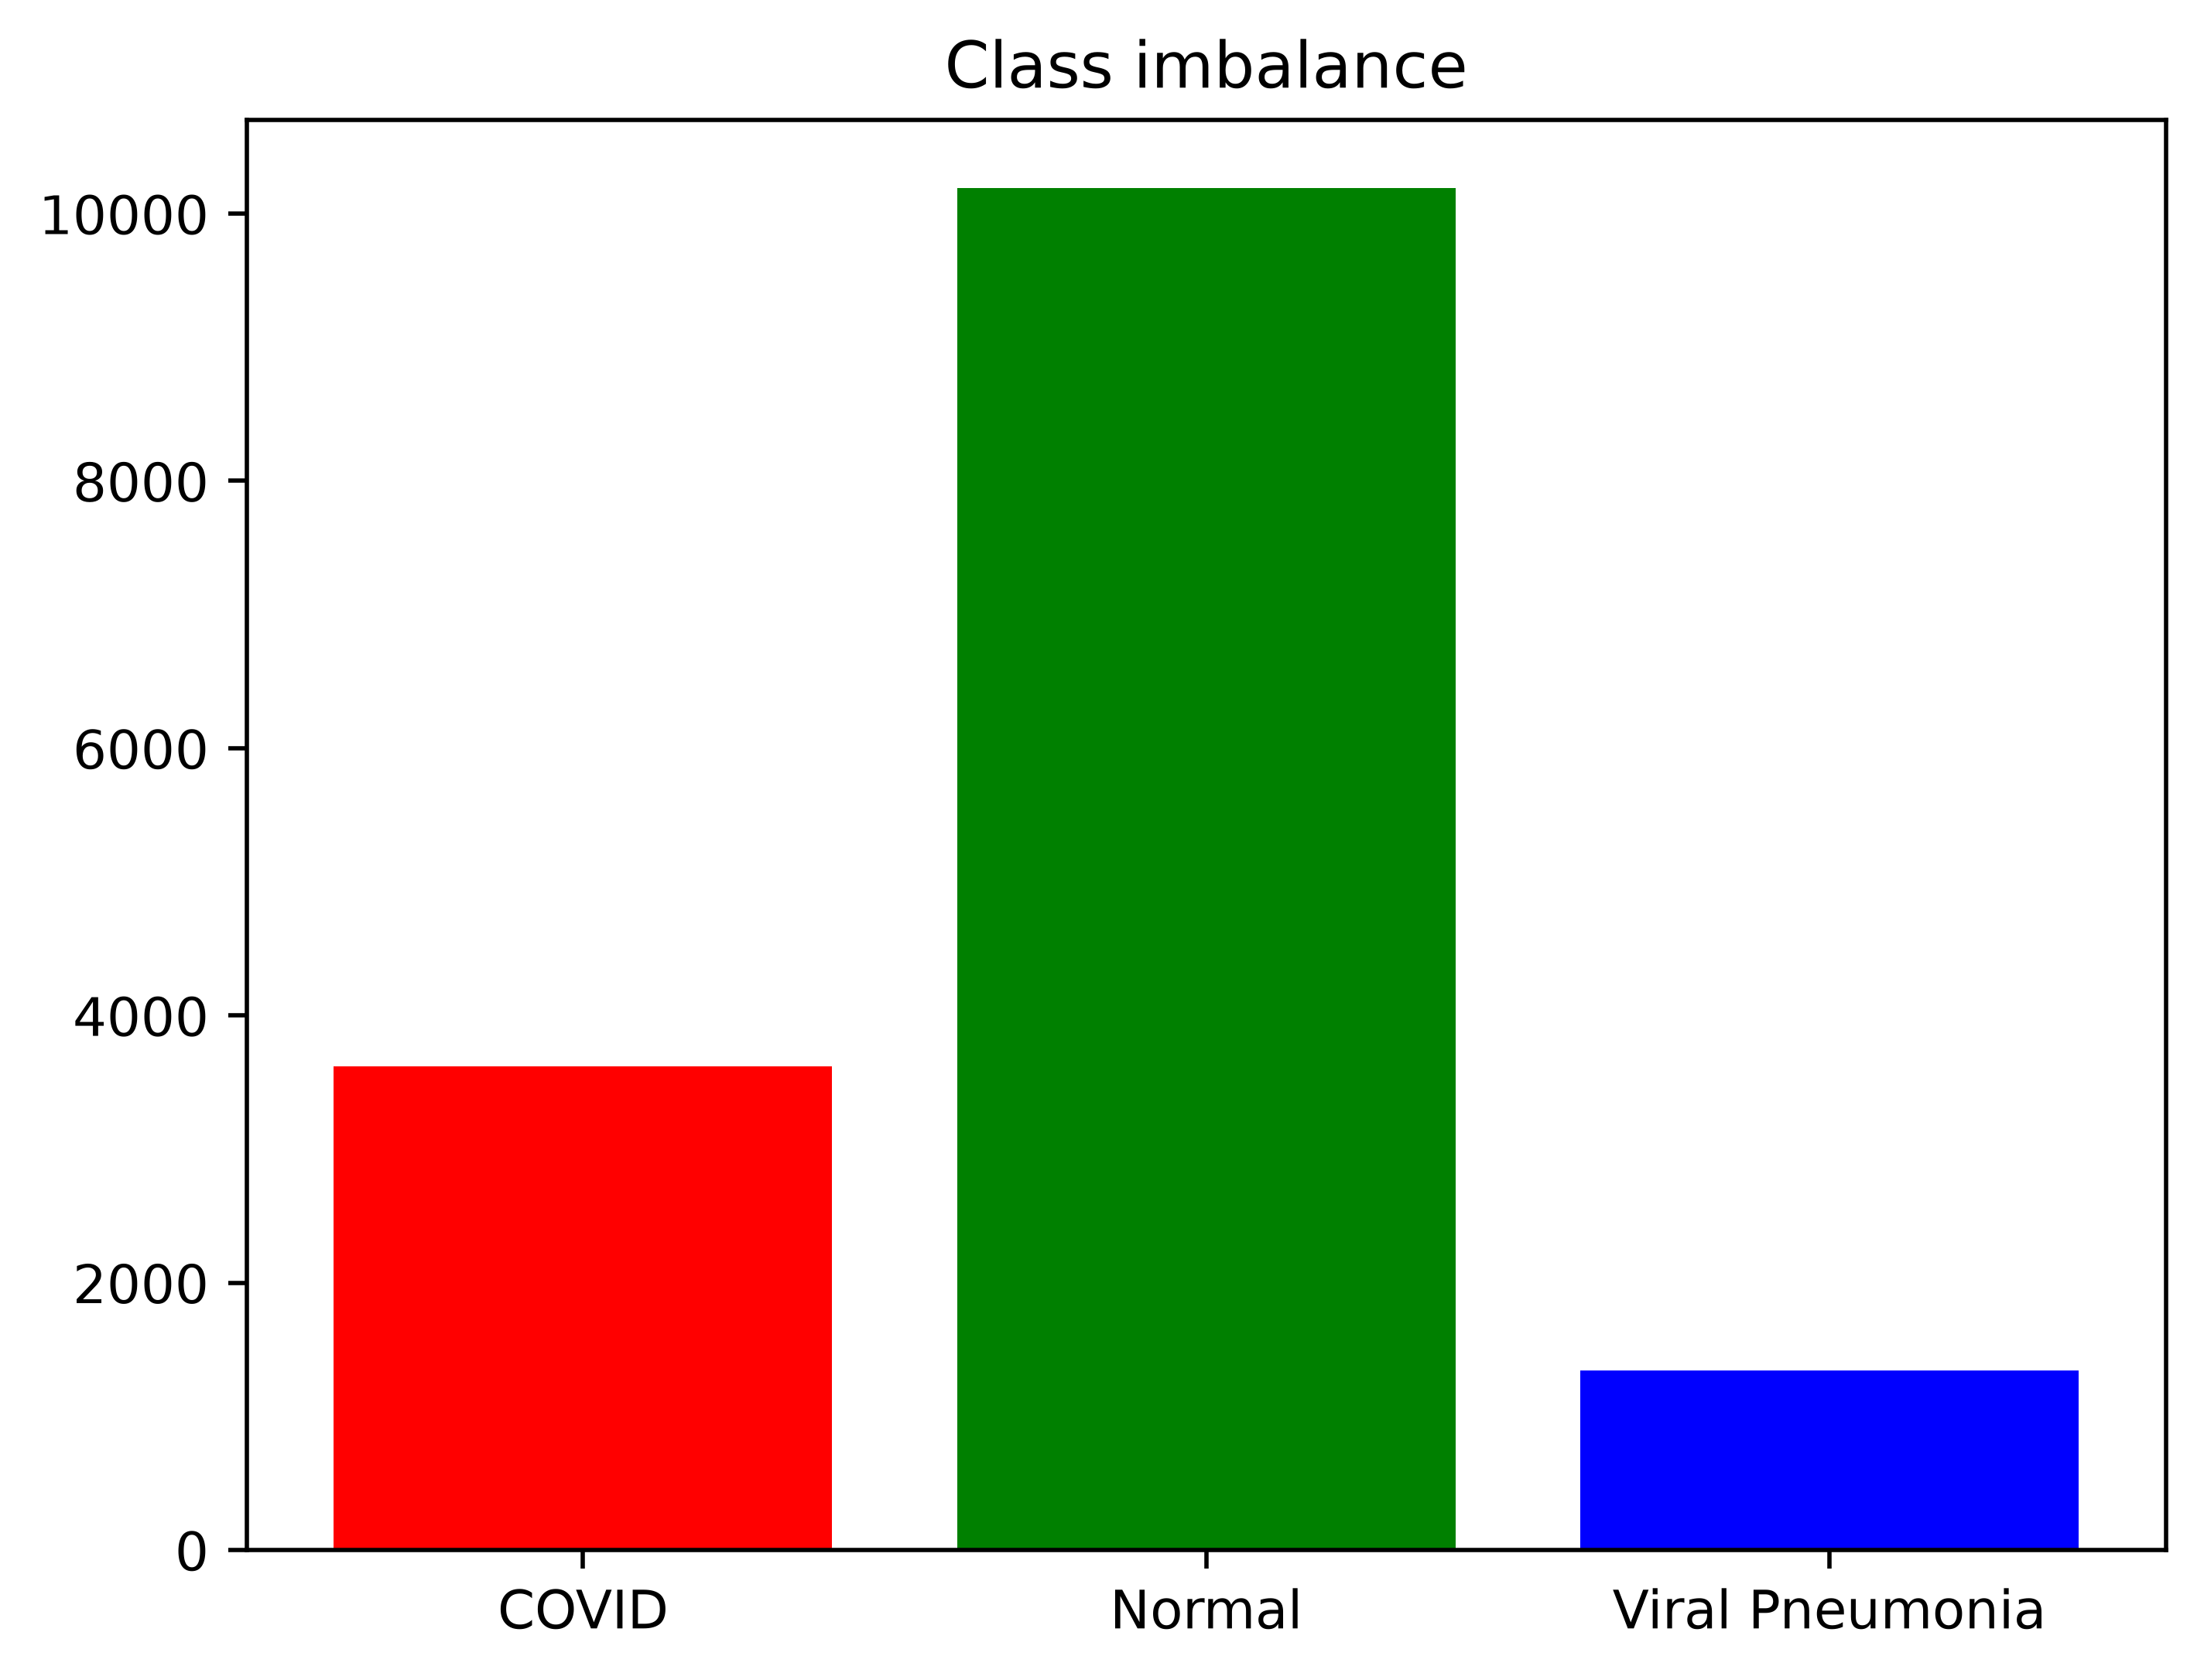

In [38]:
plt.figure(dpi=500)
plt.title("Class imbalance")
plt.bar(list(idx_to_class.values()), counts, color=['red', 'green', 'blue'])
plt.show()